# 23CSE301 Machine Learning Capstone — Review 1
## Track 2: Bank Telemarketing Classification (Part A)
**Objective:** Construct an isolated, leak-free classification pipeline evaluating the 5 required Part-A algorithms to predict term-deposit subscription (`y` $\in \{0, 1\}$). The pipeline handles class imbalance using stratified validation and weighted evaluation metrics alongside confusion matrices and decision tree visualizations.

## STEP 1: IMPORT CORE LIBRARIES

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

# 5 Required Part-A Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## Step 2: Exploratory Data Analysis (EDA)
Load the dataset using a flexible delimiter engine, standardize column names, evaluate target imbalance, and analyze client demographics.

In [4]:
#CSV file load
df_clf = pd.read_csv('bank.csv', sep=None, engine='python')

# Clean and normalize header strings
df_clf.columns = df_clf.columns.str.strip().str.replace('"', '').str.lower()
if 'deposit' in df_clf.columns and 'y' not in df_clf.columns:
    df_clf = df_clf.rename(columns={'deposit': 'y'})

print(f"Dataset Dimensions: {df_clf.shape}")
print("\n--- Missing Values Audit ---")
print(df_clf.isnull().sum())
print("\n--- Target Class Proportions ---")
print(df_clf['y'].value_counts(normalize=True))

Dataset Dimensions: (41188, 20)

--- Missing Values Audit ---
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

--- Target Class Proportions ---
y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


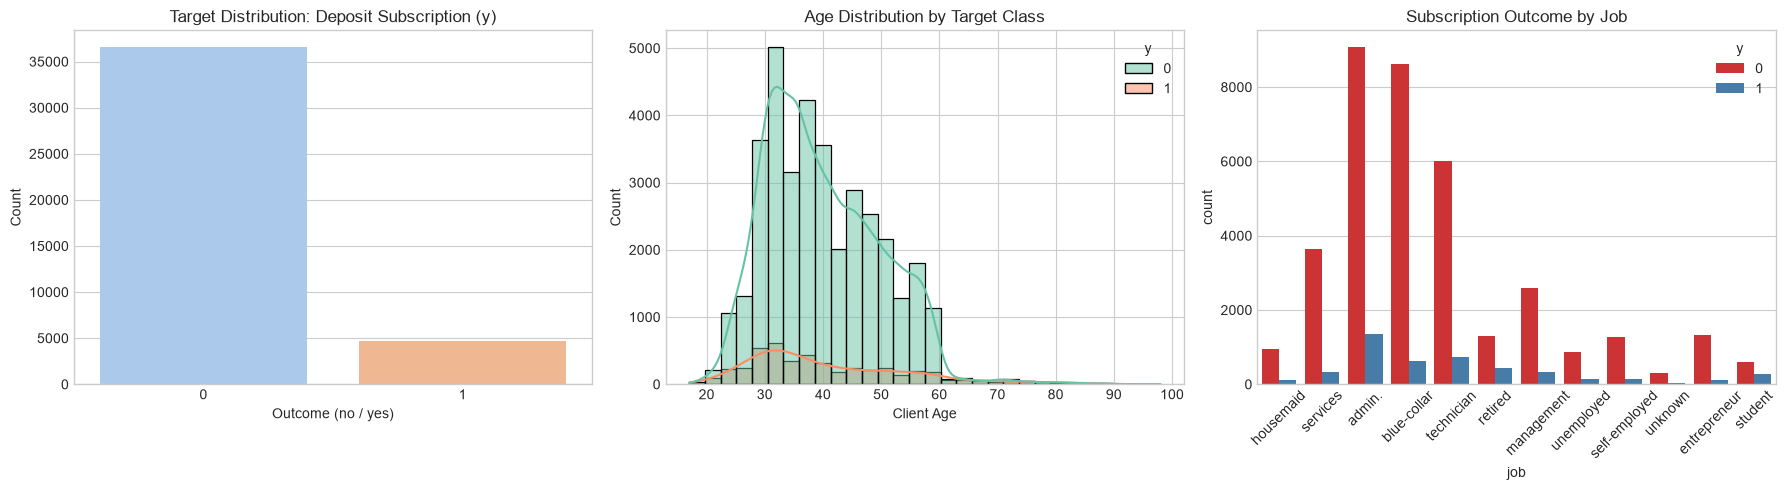

In [8]:
# EDA Visualizations: Target distribution, Age profile, and Job category breakdown
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Target Class Imbalance
sns.countplot(data=df_clf, x='y', hue='y', palette='pastel', legend=False, ax=axes[0])
axes[0].set_title('Target Distribution: Deposit Subscription (y)')
axes[0].set_xlabel('Outcome (no / yes)')
axes[0].set_ylabel('Count')

# 2. Age Distribution by Subscription Outcome
if 'age' in df_clf.columns:
    sns.histplot(data=df_clf, x='age', hue='y', kde=True, bins=30, palette='Set2', ax=axes[1])
    axes[1].set_title('Age Distribution by Target Class')
    axes[1].set_xlabel('Client Age')

# 3. Job Distribution by Outcome
if 'job' in df_clf.columns:
    sns.countplot(data=df_clf, x='job', hue='y', palette='Set1', ax=axes[2])
    axes[2].set_title('Subscription Outcome by Job')
    axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### EDA Observations:
1. **Severe Class Imbalance:** The positive class (`yes` — subscribed) comprises approximately 11.7% of entries, while the negative class (`no`) constitutes 88.3%. Accuracy alone will be a misleading performance metric, making **Weighted F1-Score, Precision, and Recall** the primary evaluation standards.
2. **Age Profile:** Subscription rates increase proportionally among younger clients (under 25) and retirees (over 60), whereas working-age professionals display lower conversion rates.
3. **Occupation Insights:** Management, technicians, and blue-collar workers form the highest outreach volume, but retirees and students yield the highest conversion percentages.